In [281]:
import pandas as pd
import numpy as np
!pip install openpyxl


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [282]:
df = pd.read_excel("../DATASETS/synthetic_ml_preprocessing_dataset.xlsx")

In [283]:
df.shape

(1010, 22)

In [284]:
df.head()

,CustomerID,Name,Age,Gender,Education,City,Country,SignupDate,LastPurchaseDate,Income,...,CreditScore,MaritalStatus,Occupation,ProductCategory,NumPurchases,WebsiteVisits,TimeOnSite,SatisfactionScore,HasDefaulted,Target
0,10000,David,19.0,Male,NaN,Chennai,US,2022-10-31,2023-09-04,60439.83,...,577.0,Divorced,Artist,Furniture,4,15,5.80,4,1,0
1,10001,David,23.0,M,NaN,Pune,USA,2020-06-10,2021-03-19,50606.00,...,703.0,Single,Doctor,Electronics,58,274,7.66,7,0,1
2,10002,Leo,31.0,M,High School,Chennai,India,2021-03-25,2022-03-10,48694.12,...,621.0,Married,Artist,Sports,59,194,16.34,9,0,0
3,10003,Eva,33.0,Male,High School,Mumbai,INDIA,2022-11-09,2023-07-19,56012.05,...,726.0,Divorced,Teacher,Luxury,46,112,59.84,3,0,0
4,10004,Ryan,66.0,Male,Master,delhi,USA,2022-11-05,2024-02-15,52306.11,...,NaN,Single,Teacher,Books,33,497,30.14,3,0,0


## ok let's handle each colomn one by one

In [285]:
# customer id - not good for prediction , so we better remove it and store it somewhere for future need
customer_id = df["CustomerID"]

In [286]:
df = df.drop(columns="CustomerID")

In [287]:
df.head(1)

,Name,Age,Gender,Education,City,Country,SignupDate,LastPurchaseDate,Income,Expenses,...,CreditScore,MaritalStatus,Occupation,ProductCategory,NumPurchases,WebsiteVisits,TimeOnSite,SatisfactionScore,HasDefaulted,Target
0,David,19.0,Male,NaN,Chennai,US,2022-10-31,2023-09-04,60439.83,52377.21,...,577.0,Divorced,Artist,Furniture,4,15,5.8,4,1,0


In [288]:
# second column - Name - drop it, not make sense
df = df.drop(columns="Name")

In [289]:
df.head(1)

,Age,Gender,Education,City,Country,SignupDate,LastPurchaseDate,Income,Expenses,LoanAmount,CreditScore,MaritalStatus,Occupation,ProductCategory,NumPurchases,WebsiteVisits,TimeOnSite,SatisfactionScore,HasDefaulted,Target
0,19.0,Male,NaN,Chennai,US,2022-10-31,2023-09-04,60439.83,52377.21,199316.55,577.0,Divorced,Artist,Furniture,4,15,5.8,4,1,0


In [290]:
# colum 3 - Age - intentionaly containing -ve values
df[df["Age"] < 0]["Age"].count()

np.int64(13)

In [291]:
# we can see that out of 1010 rows, only 13 -ve age values are there..so it's better i should drop those column
df = df[df["Age"] > 0]

In [292]:
df[df["Age"] < 0]["Age"].count()

np.int64(0)

In [293]:
# column - 4 - gender - containing inconsistent data
df["Gender"].unique()

<StringArray>
['Male', 'M', 'F', 'Female', 'female', 'male']
Length: 6, dtype: str

In [294]:
gender_map = {
    "Male" : "M",
    "M" : "M",
    "male": "M",
    "F" : "F",
    "Female": "F",
    "female": "F"
}
df["Gender"] = df["Gender"].replace(gender_map)

In [295]:
df["Gender"].unique()

<StringArray>
['M', 'F']
Length: 2, dtype: str

In [296]:
# column 5 - educational - it has levels, so highest level should get map to highest values
df["Education"].unique()

<StringArray>
[nan, 'High School', 'Master', 'PhD', 'Bachelor']
Length: 5, dtype: str

In [297]:
education_map = {
    "High School": 0,
    "Bachelor": 5,
    "Master": 10,
    "PhD": 25
}
df["Education"] = df["Education"].replace(education_map)

In [298]:
df["Education"].unique()

array([nan, 0, 10, 25, 5], dtype=object)

In [299]:
# column 6 - city - contains inconsistent data
df["City"].unique()

<StringArray>
[  'Chennai',      'Pune',    'Mumbai',     'delhi', 'Bengaluru',     'Delhi',
   'Kolkata',         nan,    'MUMBAI', 'Hyderabad']
Length: 10, dtype: str

In [300]:
city_map = {
    "Mumbai": "Mumbai",
    "MUMBAI": "Mumbai",
    "delhi": "Delhi",
    "Delhi": "Delhi"
}
df["City"] = df["City"].replace(city_map)

In [301]:
df["City"].unique()

<StringArray>
['Chennai', 'Pune', 'Mumbai', 'Delhi', 'Bengaluru', 'Kolkata', nan,
 'Hyderabad']
Length: 8, dtype: str

In [302]:
# now a customer classification is very much depend on the city also, so now i am going to assign some numeric value to them
city_score_map = {
    "Mumbai": 5,
    "Bengaluru": 4,
    "Chennai": 3,
    "Pune": 3,
    "Delhi": 2,
    "Kolkata": 1,
    "Hyderabad": 2
}
df["City"] = df["City"].replace(city_score_map)

In [303]:
df["City"].unique()

array([3, 5, 2, 4, 1, nan], dtype=object)

In [304]:
# column 7 - signup date - let's convert it to number which represent the number of days from the date till now

In [305]:
pd.to_datetime(df["SignupDate"].head(1))

0   2022-10-31
Name: SignupDate, dtype: datetime64[us]

In [306]:
import datetime
df["SignupDate"] = (datetime.datetime.today() - pd.to_datetime(df["SignupDate"])).dt.days

In [307]:
df["SignupDate"].head(5)

0    1352
1    2225
2    1937
3    1343
4    1347
Name: SignupDate, dtype: int64

In [308]:
df.head(1)

,Age,Gender,Education,City,Country,SignupDate,LastPurchaseDate,Income,Expenses,LoanAmount,CreditScore,MaritalStatus,Occupation,ProductCategory,NumPurchases,WebsiteVisits,TimeOnSite,SatisfactionScore,HasDefaulted,Target
0,19.0,M,NaN,3,US,1352,2023-09-04,60439.83,52377.21,199316.55,577.0,Divorced,Artist,Furniture,4,15,5.8,4,1,0


In [309]:
# column 8 - last purchase date - same as before
df["LastPurchaseDate"] = (datetime.datetime.today() - pd.to_datetime(df["LastPurchaseDate"])).dt.days

In [310]:
df["LastPurchaseDate"].head()

0    1044
1    1943
2    1587
3    1091
4     880
Name: LastPurchaseDate, dtype: int64

In [311]:
# and now i want to create a new column that represents, what is the time period of a customer signup and buying, or it can also represents that - what are the time span that they are with the provider (sales company)
df["ConvincedToBuy"] = df["SignupDate"] - df["LastPurchaseDate"]

In [312]:
df["ConvincedToBuy"].head(5)

0    308
1    282
2    350
3    252
4    467
Name: ConvincedToBuy, dtype: int64

In [313]:
# column 9 - Income - contains extreme outliers and missing values also
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
SI_mean = SimpleImputer(missing_values=np.nan, strategy="mean")
df[["Income"]] = SI_mean.fit_transform(df[["Income"]])

In [314]:
df["Income"].isna().sum()

np.int64(0)

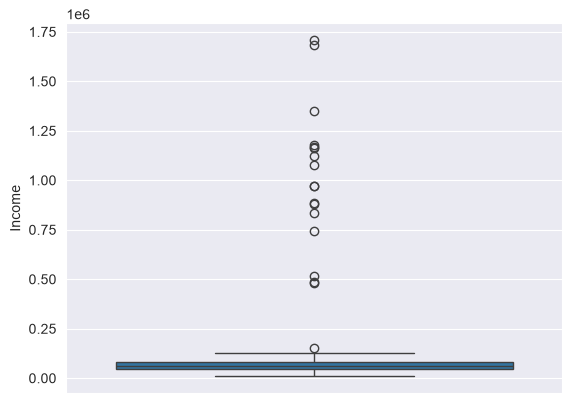

In [315]:
# now for outliers
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(df["Income"])
plt.show()

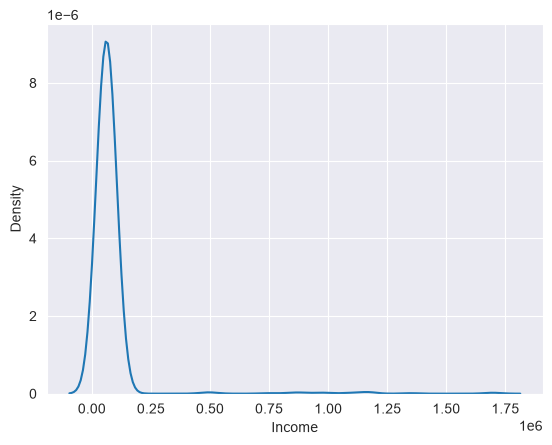

In [316]:
# it seems like right skewed
sns.kdeplot(df["Income"])
plt.show()

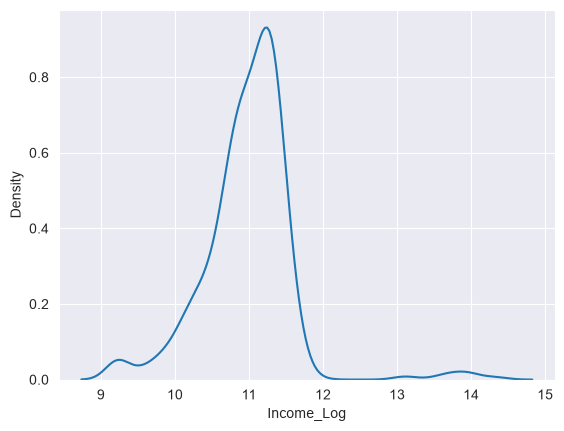

In [317]:
df["Income_Log"] = np.log1p(df["Income"])
sns.kdeplot(df["Income_Log"])
plt.show()

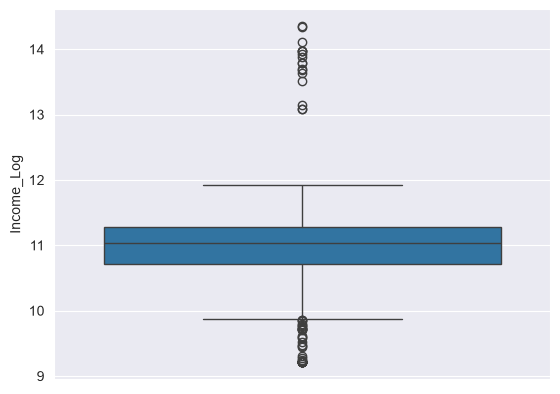

In [318]:
sns.boxplot(df["Income_Log"])
plt.show()

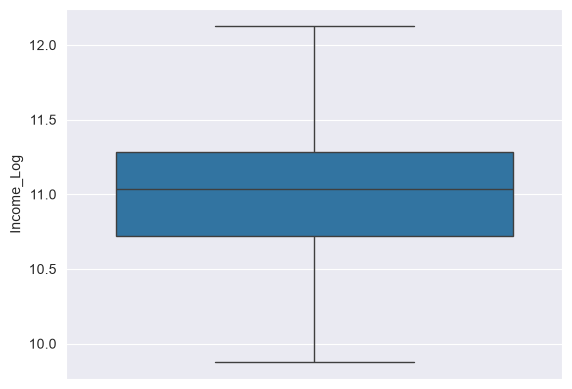

In [319]:
Q1 = np.quantile(df["Income_Log"], 0.25)
Q3 = np.quantile(df["Income_Log"], 0.75)

IQR = Q3 - Q1
lower_b = Q1 - (1.5 * IQR)
upper_b = Q3 + (1.5 * IQR)

df["Income_Log"] = np.clip(df["Income_Log"], lower_b, upper_b)
sns.boxplot(df["Income_Log"])
plt.show()

In [320]:
# column 10 - expenses - same as before
df["Expenses"].head(5)

0    52377.21
1    25786.80
2    37566.57
3    48860.01
4         NaN
Name: Expenses, dtype: float64

In [321]:
df[["Expenses"]] = SI_mean.fit_transform(df[["Expenses"]])

[]

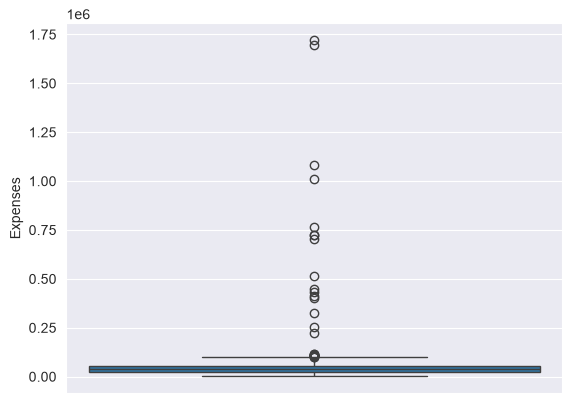

In [322]:
sns.boxplot(df["Expenses"])
plt.plot()

[]

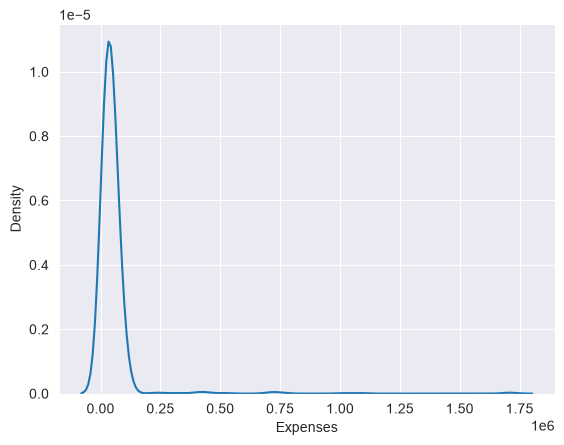

In [323]:
sns.kdeplot(df["Expenses"])
plt.plot()

[]

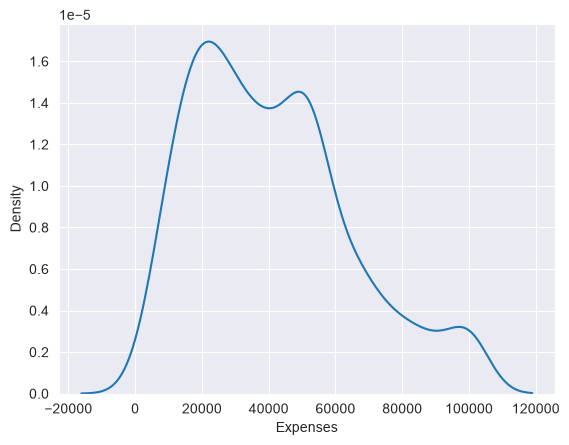

In [324]:
# so same as before
Q1 = np.quantile(df["Expenses"], 0.25)
Q3 = np.quantile(df["Expenses"], 0.75)

IQR = Q3 - Q1

lower_b = Q1 - (1.5 * IQR)
upper_b = Q3 + (1.5 * IQR)

df["Expenses"] = np.clip(df["Expenses"], lower_b, upper_b)

sns.kdeplot(df["Expenses"])
plt.plot()

[]

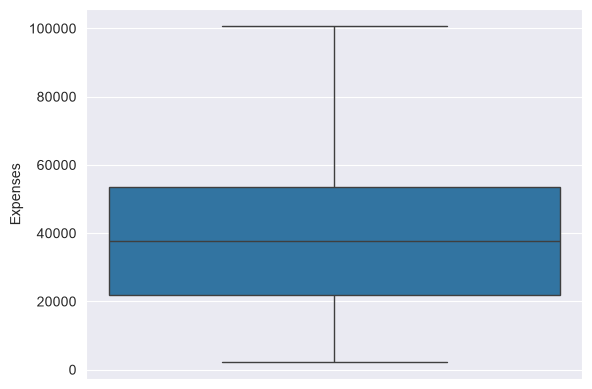

In [325]:
sns.boxplot(df["Expenses"])
plt.plot()

In [326]:
# column 11 - loan amount - same as before
df[["LoanAmount"]] = SI_mean.fit_transform(df[["LoanAmount"]])

[]

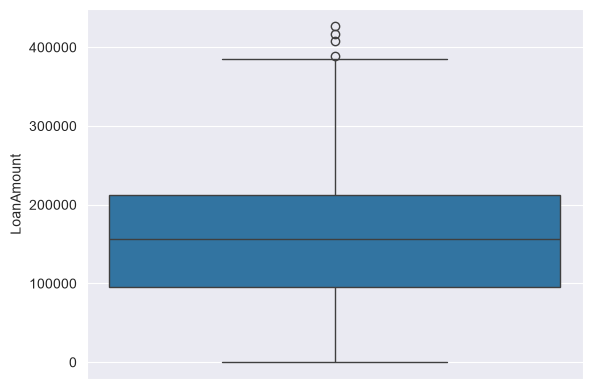

In [327]:
sns.boxplot(df["LoanAmount"])
plt.plot()

[]

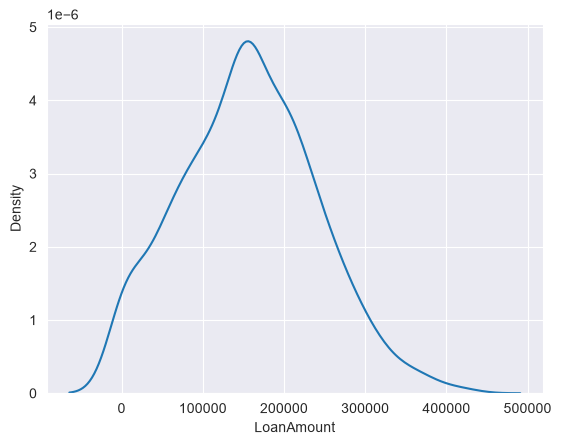

In [328]:
sns.kdeplot(df["LoanAmount"])
plt.plot()

[]

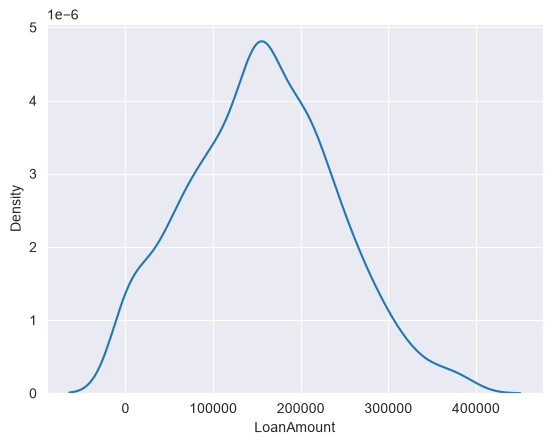

In [329]:
# so same as before
Q1 = np.quantile(df["LoanAmount"], 0.25)
Q3 = np.quantile(df["LoanAmount"], 0.75)

IQR = Q3 - Q1

lower_b = Q1 - (1.5 * IQR)
upper_b = Q3 + (1.5 * IQR)

df["LoanAmount"] = np.clip(df["LoanAmount"], lower_b, upper_b)

sns.kdeplot(df["LoanAmount"])
plt.plot()

[]

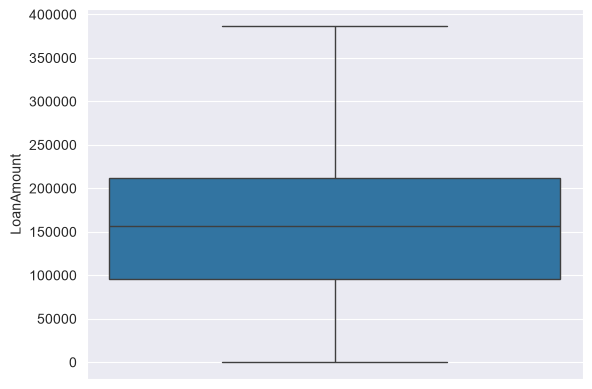

In [330]:
sns.boxplot(df["LoanAmount"])
plt.plot()

In [331]:
# column 12 - credit score (300 - 900), and some missing values
df[["CreditScore"]] = SI_mean.fit_transform(df[["CreditScore"]])

In [332]:
df["CreditScore"].min()

np.float64(401.0)

In [333]:
df["CreditScore"].max()

np.float64(900.0)

[]

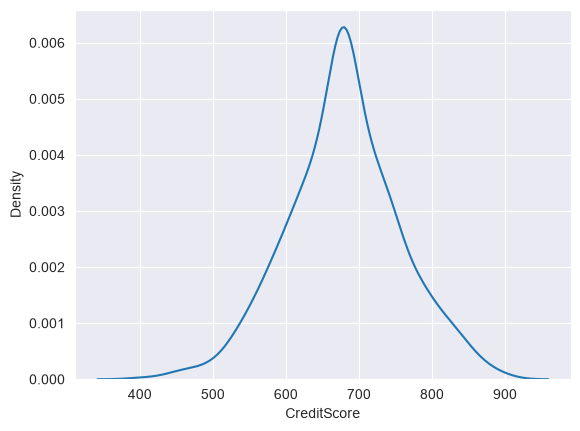

In [334]:
sns.kdeplot(df["CreditScore"])
plt.plot()

[]

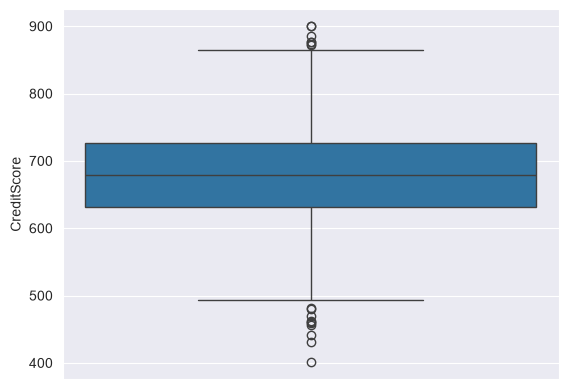

In [335]:
sns.boxplot(df["CreditScore"])
plt.plot()

In [336]:
# since the data is normally distributed, i will go for z score method, to handle outliers
mean = df["CreditScore"].mean()
std = df["CreditScore"].std()

lower_b = mean - 3 * std
upper_b = mean + 3 * std

df["CreditScore"] = df["CreditScore"].clip(lower_b, upper_b)


In [337]:
df.columns

Index(['Age', 'Gender', 'Education', 'City', 'Country', 'SignupDate',
       'LastPurchaseDate', 'Income', 'Expenses', 'LoanAmount', 'CreditScore',
       'MaritalStatus', 'Occupation', 'ProductCategory', 'NumPurchases',
       'WebsiteVisits', 'TimeOnSite', 'SatisfactionScore', 'HasDefaulted',
       'Target', 'ConvincedToBuy', 'Income_Log'],
      dtype='str')

[]

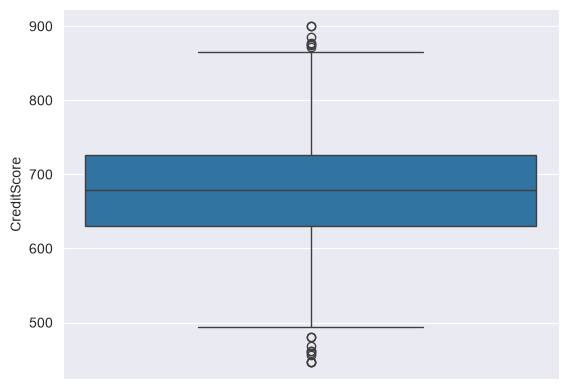

In [338]:
sns.boxplot(df["CreditScore"])
plt.plot()

In [339]:
df["CreditScore"].min()

np.float64(446.50213132751253)

In [340]:
df["CreditScore"].max()

np.float64(900.0)

In [341]:
# column 13 - marital status
df["MaritalStatus"].unique()

<StringArray>
['Divorced', 'Single', 'Married']
Length: 3, dtype: str

In [342]:
marital_map = {
    "Divorced": 5,
    "Single": 10,
    "Married": 15
}
df["MaritalStatus"] = df["MaritalStatus"].replace(marital_map)

In [343]:
df["MaritalStatus"].unique()

array([5, 10, 15], dtype=object)

In [344]:
# column 14 - occupation - missing values
df["Occupation"].unique()

<StringArray>
['Artist', 'Doctor', 'Teacher', 'Engineer', 'Student', 'Lawyer', 'Business',
 nan]
Length: 8, dtype: str

In [345]:
# it does not make sense that a certain occupation can be a good customer, so for that i will use here - One hot encoder
df = pd.get_dummies(df, columns=["Occupation"], sparse=True, dtype=int)

In [346]:
df.columns

Index(['Age', 'Gender', 'Education', 'City', 'Country', 'SignupDate',
       'LastPurchaseDate', 'Income', 'Expenses', 'LoanAmount', 'CreditScore',
       'MaritalStatus', 'ProductCategory', 'NumPurchases', 'WebsiteVisits',
       'TimeOnSite', 'SatisfactionScore', 'HasDefaulted', 'Target',
       'ConvincedToBuy', 'Income_Log', 'Occupation_Artist',
       'Occupation_Business', 'Occupation_Doctor', 'Occupation_Engineer',
       'Occupation_Lawyer', 'Occupation_Student', 'Occupation_Teacher'],
      dtype='str')

In [347]:
# column 15 - product category
df["ProductCategory"].unique()

<StringArray>
[  'Furniture', 'Electronics',      'Sports',      'Luxury',       'Books',
           nan,    'Clothing',      'Beauty',   'Groceries']
Length: 9, dtype: str

In [348]:
# now for this i can use Label Encoder, because each category may contain some weight that helps our model
from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
df["ProductCategory"] = LE.fit_transform(df["ProductCategory"])

In [349]:
df["ProductCategory"].unique()

array([4, 3, 7, 6, 1, 8, 2, 0, 5])

In [350]:
df.columns

Index(['Age', 'Gender', 'Education', 'City', 'Country', 'SignupDate',
       'LastPurchaseDate', 'Income', 'Expenses', 'LoanAmount', 'CreditScore',
       'MaritalStatus', 'ProductCategory', 'NumPurchases', 'WebsiteVisits',
       'TimeOnSite', 'SatisfactionScore', 'HasDefaulted', 'Target',
       'ConvincedToBuy', 'Income_Log', 'Occupation_Artist',
       'Occupation_Business', 'Occupation_Doctor', 'Occupation_Engineer',
       'Occupation_Lawyer', 'Occupation_Student', 'Occupation_Teacher'],
      dtype='str')

In [351]:
# column 16 - Number of purchases
df[df["NumPurchases"].isna() == True]

,Age,Gender,Education,City,Country,SignupDate,LastPurchaseDate,Income,Expenses,LoanAmount,...,Target,ConvincedToBuy,Income_Log,Occupation_Artist,Occupation_Business,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Student,Occupation_Teacher


[]

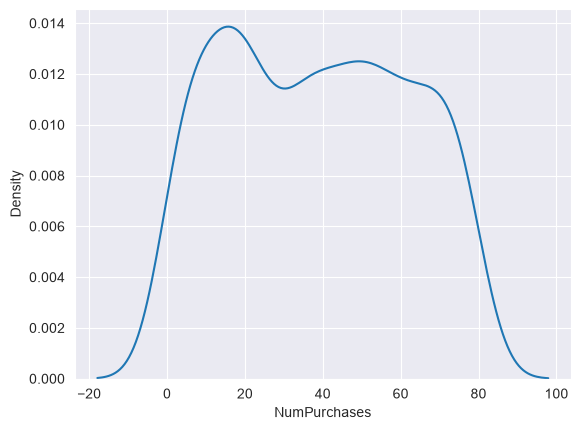

In [352]:
sns.kdeplot(df["NumPurchases"])
plt.plot()

[]

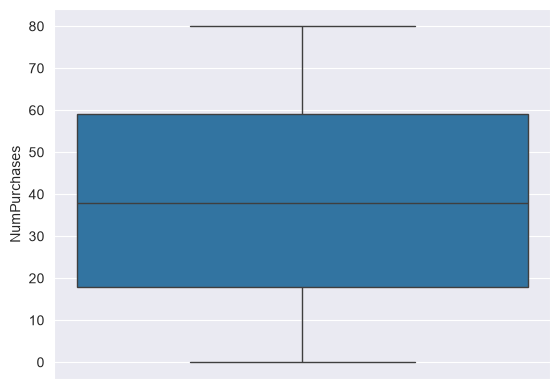

In [353]:
sns.boxplot(df["NumPurchases"])
plt.plot()

In [354]:
df["NumPurchases"].min()

np.int64(0)

In [355]:
df["NumPurchases"].max()

np.int64(80)

In [356]:
# column - 17 - number of times website visits
df[df["WebsiteVisits"].isna() == True]

,Age,Gender,Education,City,Country,SignupDate,LastPurchaseDate,Income,Expenses,LoanAmount,...,Target,ConvincedToBuy,Income_Log,Occupation_Artist,Occupation_Business,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Student,Occupation_Teacher


[]

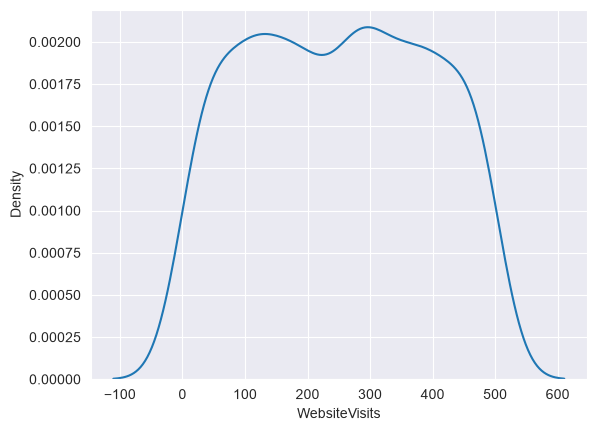

In [357]:
sns.kdeplot(df["WebsiteVisits"])
plt.plot()

[]

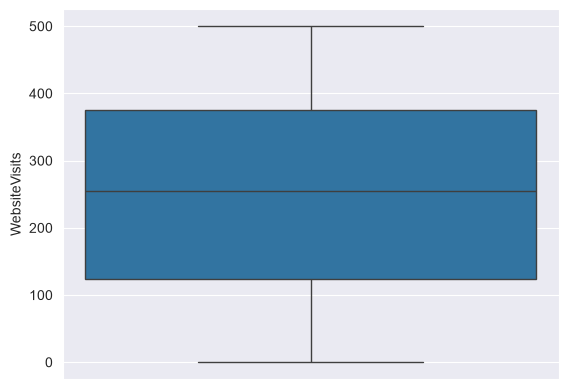

In [358]:
sns.boxplot(df["WebsiteVisits"])
plt.plot()

In [359]:
# column 18 - time on website
df[df["TimeOnSite"].isna() == True]

,Age,Gender,Education,City,Country,SignupDate,LastPurchaseDate,Income,Expenses,LoanAmount,...,Target,ConvincedToBuy,Income_Log,Occupation_Artist,Occupation_Business,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Student,Occupation_Teacher


[]

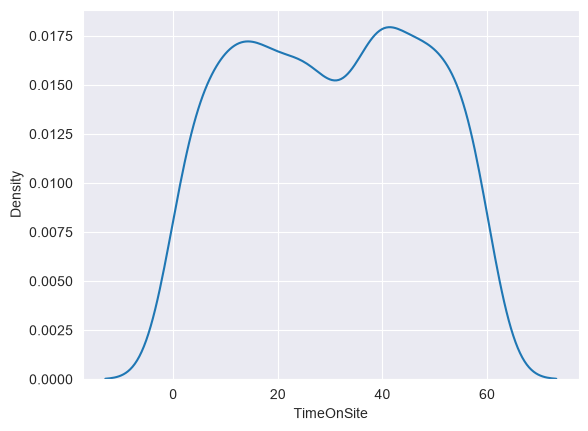

In [360]:
sns.kdeplot(df["TimeOnSite"])
plt.plot()

[]

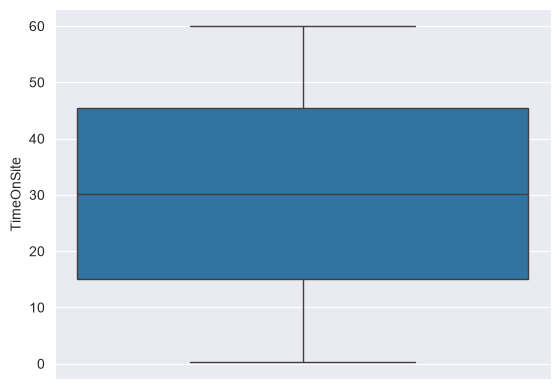

In [361]:
sns.boxplot(df["TimeOnSite"])
plt.plot()

In [362]:
# column - 19 - satisfaction level
df[df["SatisfactionScore"].isna() == True]

,Age,Gender,Education,City,Country,SignupDate,LastPurchaseDate,Income,Expenses,LoanAmount,...,Target,ConvincedToBuy,Income_Log,Occupation_Artist,Occupation_Business,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Student,Occupation_Teacher


[]

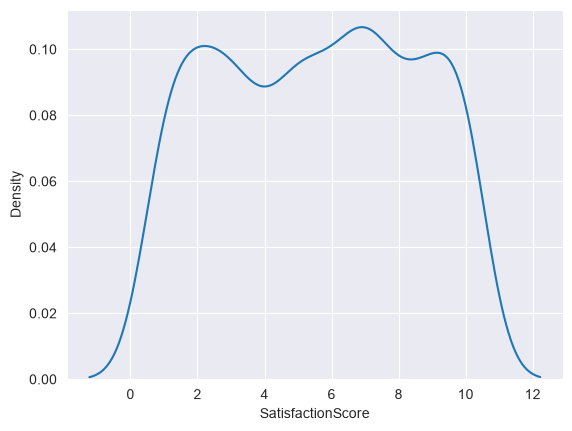

In [363]:
sns.kdeplot(df["SatisfactionScore"])
plt.plot()

[]

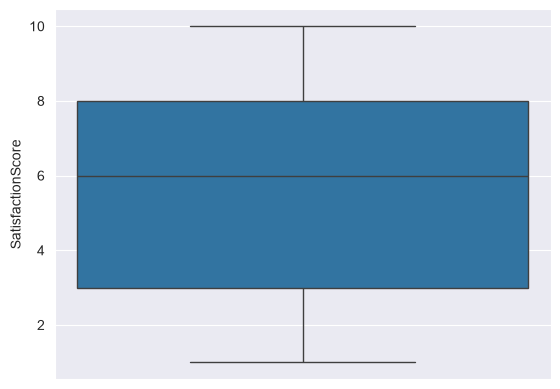

In [364]:
sns.boxplot(df["SatisfactionScore"])
plt.plot()

In [365]:
# column 20 - has on loan - 0 means not loan , 1 mean not loan
df[df["HasDefaulted"].isna() == True]

,Age,Gender,Education,City,Country,SignupDate,LastPurchaseDate,Income,Expenses,LoanAmount,...,Target,ConvincedToBuy,Income_Log,Occupation_Artist,Occupation_Business,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Student,Occupation_Teacher


[]

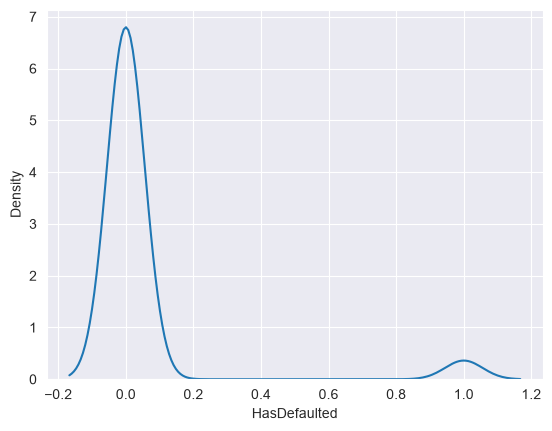

In [366]:
sns.kdeplot(df["HasDefaulted"])
plt.plot()

In [367]:
# so, this is left skewed, let's make it normal distribution - but we should not because it represents the 0 and 1 value for has defaulted or not, if we make it normal, the data will corrupt
df["HasDefaulted"].min()

np.int64(0)

In [368]:
df["HasDefaulted"].max()

np.int64(1)

In [369]:
# now we have the 21th column - which is our target, no need to modify it at all
df["Target"].unique()

array([0, 1])

## Now let's do all the standardization, handle missing values, categorization

In [370]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

In [371]:
df.head(5)

,Age,Gender,Education,City,Country,SignupDate,LastPurchaseDate,Income,Expenses,LoanAmount,...,Target,ConvincedToBuy,Income_Log,Occupation_Artist,Occupation_Business,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Student,Occupation_Teacher
0,19.0,M,NaN,3,US,1352,1044,60439.83,52377.210000,199316.55,...,0,308,11.009420,1,0,0,0,0,0,0
1,23.0,M,NaN,3,USA,2225,1943,50606.00,25786.800000,147555.84,...,1,282,10.831845,0,0,1,0,0,0,0
2,31.0,M,0,3,India,1937,1587,48694.12,37566.570000,19681.72,...,0,350,10.793334,1,0,0,0,0,0,0
3,33.0,M,0,5,INDIA,1343,1091,56012.05,48860.010000,42718.36,...,0,252,10.933340,0,0,0,0,0,0,1
4,66.0,M,10,2,USA,1347,880,52306.11,51739.168301,116103.88,...,0,467,10.864888,0,0,0,0,0,0,1


In [372]:
df

,Age,Gender,Education,City,Country,SignupDate,LastPurchaseDate,Income,Expenses,LoanAmount,...,Target,ConvincedToBuy,Income_Log,Occupation_Artist,Occupation_Business,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Student,Occupation_Teacher
0,19.0,M,NaN,3,US,1352,1044,60439.83,52377.210000,199316.55,...,0,308,11.009420,1,0,0,0,0,0,0
1,23.0,M,NaN,3,USA,2225,1943,50606.00,25786.800000,147555.84,...,1,282,10.831845,0,0,1,0,0,0,0
2,31.0,M,0,3,India,1937,1587,48694.12,37566.570000,19681.72,...,0,350,10.793334,1,0,0,0,0,0,0
3,33.0,M,0,5,INDIA,1343,1091,56012.05,48860.010000,42718.36,...,0,252,10.933340,0,0,0,0,0,0,1
4,66.0,M,10,2,USA,1347,880,52306.11,51739.168301,116103.88,...,0,467,10.864888,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,66.0,M,10,2,USA,1347,880,52306.11,51739.168301,116103.88,...,0,467,10.864888,0,0,0,0,0,0,1
1005,33.0,F,NaN,4,india,2124,1787,45388.26,47760.000000,239155.77,...,0,337,10.723031,1,0,0,0,0,0,0
1006,32.0,F,10,2,INDIA,2241,1978,91488.93,18889.880000,165069.76,...,1,263,11.423984,0,0,0,0,0,0,1
1007,21.0,M,25,2,India,1439,1312,51594.72,50330.920000,150493.56,...,0,127,10.851194,0,0,0,1,0,0,0


In [373]:
for col in df.columns:
    print(f"{col} have {df[col].isna().sum()} nan values")

Age have 0 nan values
Gender have 0 nan values
Education have 229 nan values
City have 56 nan values
Country have 0 nan values
SignupDate have 0 nan values
LastPurchaseDate have 0 nan values
Income have 0 nan values
Expenses have 0 nan values
LoanAmount have 0 nan values
CreditScore have 0 nan values
MaritalStatus have 0 nan values
ProductCategory have 0 nan values
NumPurchases have 0 nan values
WebsiteVisits have 0 nan values
TimeOnSite have 0 nan values
SatisfactionScore have 0 nan values
HasDefaulted have 0 nan values
Target have 0 nan values
ConvincedToBuy have 0 nan values
Income_Log have 0 nan values
Occupation_Artist have 0 nan values
Occupation_Business have 0 nan values
Occupation_Doctor have 0 nan values
Occupation_Engineer have 0 nan values
Occupation_Lawyer have 0 nan values
Occupation_Student have 0 nan values
Occupation_Teacher have 0 nan values


In [374]:
# so, education and city have some missing values

In [375]:
# and for education , i want to make use of most frequent method, not mean

In [376]:
SI_mode = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
df[["Education"]] = SI_mode.fit_transform(df[["Education"]])

In [377]:
# same for city also
df[["City"]] = SI_mode.fit_transform(df[["City"]])

In [378]:
df["Education"].isna().sum()

np.int64(0)

In [379]:
df["City"].isna().sum()

np.int64(0)

In [380]:
df.head(5)

,Age,Gender,Education,City,Country,SignupDate,LastPurchaseDate,Income,Expenses,LoanAmount,...,Target,ConvincedToBuy,Income_Log,Occupation_Artist,Occupation_Business,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Student,Occupation_Teacher
0,19.0,M,5,3,US,1352,1044,60439.83,52377.210000,199316.55,...,0,308,11.009420,1,0,0,0,0,0,0
1,23.0,M,5,3,USA,2225,1943,50606.00,25786.800000,147555.84,...,1,282,10.831845,0,0,1,0,0,0,0
2,31.0,M,0,3,India,1937,1587,48694.12,37566.570000,19681.72,...,0,350,10.793334,1,0,0,0,0,0,0
3,33.0,M,0,5,INDIA,1343,1091,56012.05,48860.010000,42718.36,...,0,252,10.933340,0,0,0,0,0,0,1
4,66.0,M,10,2,USA,1347,880,52306.11,51739.168301,116103.88,...,0,467,10.864888,0,0,0,0,0,0,1


In [381]:
cat_col = df.select_dtypes(include=["object", "str"]).columns
df[cat_col]

,Gender,Education,City,Country,MaritalStatus
0,M,5,3,US,5
1,M,5,3,USA,10
2,M,0,3,India,15
3,M,0,5,INDIA,5
4,M,10,2,USA,10
...,...,...,...,...,...
1004,M,10,2,USA,10
1005,F,5,4,india,5
1006,F,10,2,INDIA,5
1007,M,25,2,India,10


In [382]:
# for encoding part - i will use column - [Gender] as Binary encoding
# [Country] as Label encoder
# and rest only convert to integer

In [383]:
df[["Education", "City", "MaritalStatus"]] = df[["Education", "City", "MaritalStatus"]].astype("int")

In [384]:
cat_col = df.select_dtypes(include=["object", "str"]).columns
df[cat_col]

,Gender,Country
0,M,US
1,M,USA
2,M,India
3,M,INDIA
4,M,USA
...,...,...
1004,M,USA
1005,F,india
1006,F,INDIA
1007,M,India


In [385]:
gender_encode = {
    "M": 1,
    "F": 0
}
df["Gender"] = df["Gender"].replace(gender_encode).astype(int)

In [386]:
OE = OrdinalEncoder()
df[["Country"]] = OE.fit_transform(df[["Country"]])

In [387]:
cat_col = df.select_dtypes(include=["object", "str"]).columns
df[cat_col]

""
0
1
2
3
4
...
1004
1005
1006
1007


In [388]:
# now i have encoded all the cat columns into respective numeric columns

In [389]:
# so let's start the scaling preprocessing

In [390]:
num_cols = df.select_dtypes(include=["int", "float"]).columns
num_cols

Index(['Age', 'Gender', 'Education', 'City', 'Country', 'SignupDate',
       'LastPurchaseDate', 'Income', 'Expenses', 'LoanAmount', 'CreditScore',
       'MaritalStatus', 'ProductCategory', 'NumPurchases', 'WebsiteVisits',
       'TimeOnSite', 'SatisfactionScore', 'HasDefaulted', 'Target',
       'ConvincedToBuy', 'Income_Log', 'Occupation_Artist',
       'Occupation_Business', 'Occupation_Doctor', 'Occupation_Engineer',
       'Occupation_Lawyer', 'Occupation_Student', 'Occupation_Teacher'],
      dtype='str')

In [391]:
len(num_cols)

28

In [392]:
col_need_scale = [col for col in num_cols if df[col].nunique() > 10]
col_need_scale

['Age',
 'SignupDate',
 'LastPurchaseDate',
 'Income',
 'Expenses',
 'LoanAmount',
 'CreditScore',
 'NumPurchases',
 'WebsiteVisits',
 'TimeOnSite',
 'ConvincedToBuy',
 'Income_Log']

In [393]:
SC = StandardScaler()
df[col_need_scale] = SC.fit_transform(df[col_need_scale])

In [394]:
df.head()

,Age,Gender,Education,City,Country,SignupDate,LastPurchaseDate,Income,Expenses,LoanAmount,...,Target,ConvincedToBuy,Income_Log,Occupation_Artist,Occupation_Business,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Student,Occupation_Teacher
0,-1.372281,1,5,3,2.0,-0.236306,-0.330785,-0.134725,0.470317,0.513635,...,0,0.389517,0.090601,1,0,0,0,0,0,0
1,-1.157622,1,5,3,3.0,1.448657,1.327335,-0.206073,-0.640711,-0.104009,...,1,0.211568,-0.287945,0,0,1,0,0,0,0
2,-0.728302,1,0,3,1.0,0.892793,0.670727,-0.219944,-0.148516,-1.629891,...,0,0.676973,-0.370041,1,0,0,0,0,0,0
3,-0.620972,1,0,5,0.0,-0.253677,-0.244098,-0.166850,0.323358,-1.355002,...,0,0.006243,-0.071583,0,0,0,0,0,0,1
4,1.149972,1,10,2,3.0,-0.245956,-0.633267,-0.193738,0.443658,-0.479316,...,0,1.477743,-0.217507,0,0,0,0,0,0,1


In [395]:
# alright..oowh...let's do the training

In [396]:
df.columns


Index(['Age', 'Gender', 'Education', 'City', 'Country', 'SignupDate',
       'LastPurchaseDate', 'Income', 'Expenses', 'LoanAmount', 'CreditScore',
       'MaritalStatus', 'ProductCategory', 'NumPurchases', 'WebsiteVisits',
       'TimeOnSite', 'SatisfactionScore', 'HasDefaulted', 'Target',
       'ConvincedToBuy', 'Income_Log', 'Occupation_Artist',
       'Occupation_Business', 'Occupation_Doctor', 'Occupation_Engineer',
       'Occupation_Lawyer', 'Occupation_Student', 'Occupation_Teacher'],
      dtype='str')

In [399]:
print(df.select_dtypes(include=['object', 'category']).columns)

Index([], dtype='str')


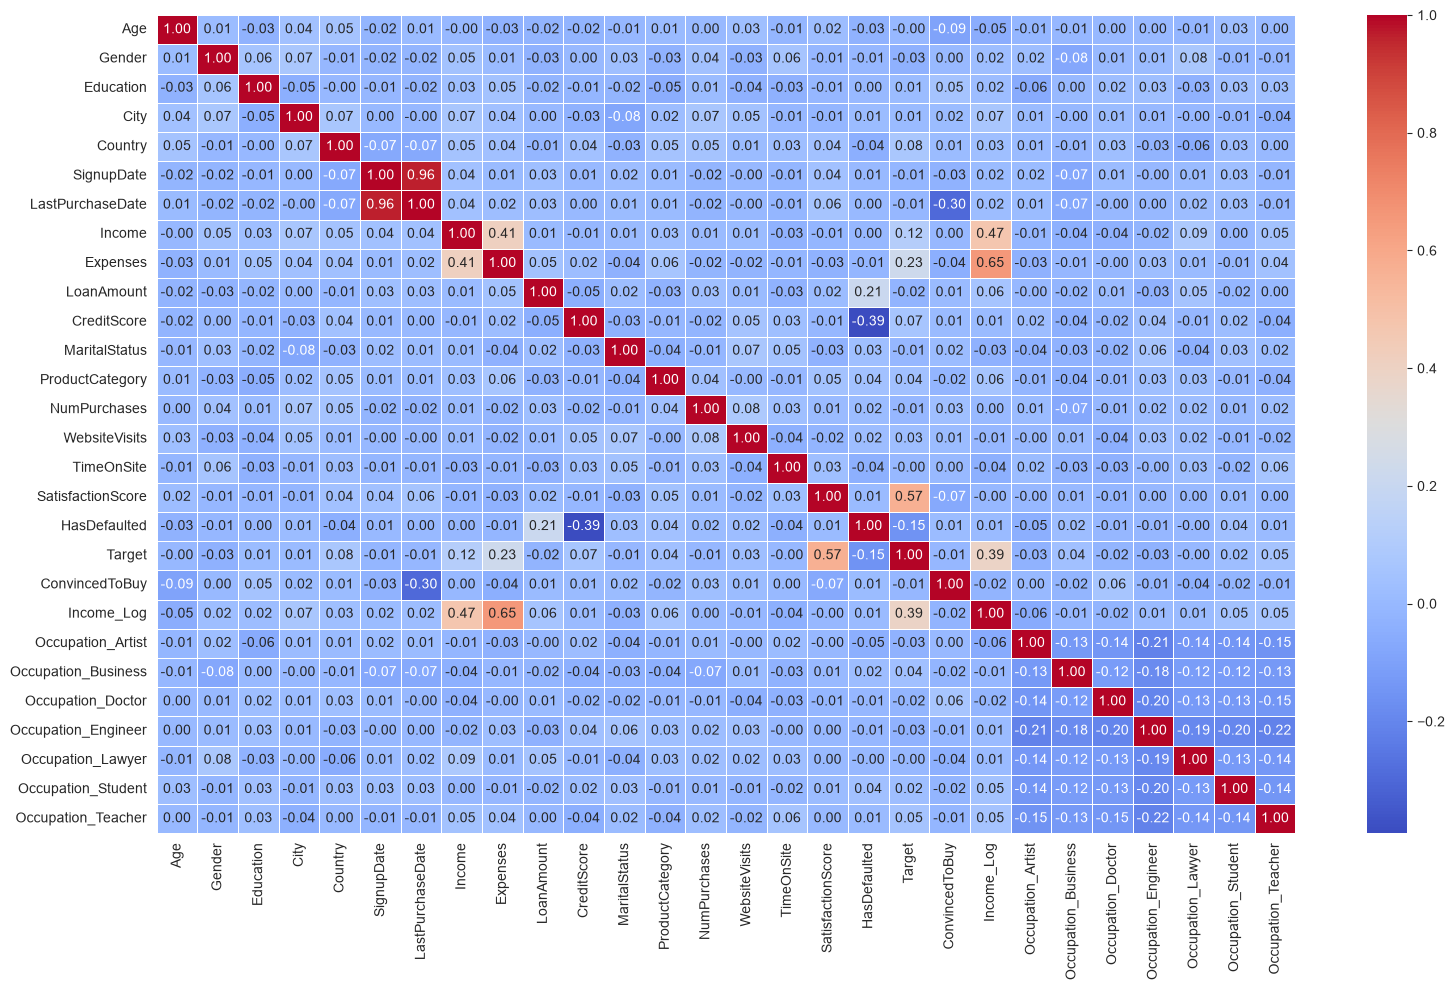

In [423]:
plt.figure(figsize=(16, 10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.tight_layout()
plt.show()

In [400]:
# but before that we have to split out dataset into training and testing purpose
y = df["Target"].values
X = df.drop("Target", axis=1).values

In [401]:
y[:5]

array([0, 1, 0, 0, 0])

In [404]:
X[:1]

array([[-1.37228133,  1.        ,  5.        ,  3.        ,  2.        ,
        -0.23630595, -0.33078493, -0.13472496,  0.47031736,  0.51363525,
        -1.32118712,  5.        ,  4.        , -1.47699284, -1.62718698,
        -1.40923825,  4.        ,  1.        ,  0.38951704,  0.09060063,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ]])

In [405]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [406]:
# because we have target value as class 0 and 1, so i need a classification algorithm for this

In [407]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [408]:
Log_model = LogisticRegression(max_iter=1000)
Log_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [409]:
RF_model = RandomForestClassifier(n_estimators=220, random_state=42)
RF_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",220
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [410]:
KN_model = KNeighborsClassifier(n_neighbors=5)
KN_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [411]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [412]:
LOG_y_predict = Log_model.predict(X_test)
RF_y_predict = RF_model.predict(X_test)
KN_y_predict = KN_model.predict(X_test)

In [413]:
log_acc = accuracy_score(y_test, LOG_y_predict)
rf_acc = accuracy_score(y_test, RF_y_predict)
kn_acc = accuracy_score(y_test, KN_y_predict)

In [414]:
log_acc

0.9197860962566845

In [416]:
rf_acc

0.9946524064171123

In [417]:
kn_acc

0.839572192513369

In [418]:
confusion_matrix(y_test, LOG_y_predict)

array([[119,   6],
       [  9,  53]])

In [419]:
confusion_matrix(y_test, RF_y_predict)

array([[125,   0],
       [  1,  61]])

In [420]:
confusion_matrix(y_test, KN_y_predict)

array([[110,  15],
       [ 15,  47]])

In [424]:
from sklearn.metrics import classification_report
print(classification_report(y_test, RF_y_predict))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       125
           1       1.00      0.98      0.99        62

    accuracy                           0.99       187
   macro avg       1.00      0.99      0.99       187
weighted avg       0.99      0.99      0.99       187



In [427]:
importances = RF_model.feature_importances_
importances

array([0.01625759, 0.00216324, 0.00433935, 0.00681843, 0.01154302,
       0.01619171, 0.01814555, 0.15737116, 0.04044068, 0.0147065 ,
       0.02471555, 0.00510011, 0.00935233, 0.01671572, 0.01725347,
       0.01923004, 0.43871388, 0.02674657, 0.01519346, 0.12930257,
       0.00069674, 0.00134241, 0.00109937, 0.00165593, 0.00128607,
       0.00193254, 0.00168601])

In [429]:
weights_df = pd.DataFrame({'Feature': pd.DataFrame(X).columns, 'Importance': importances})
print(weights_df.sort_values(by='Importance', ascending=False).head(5))

    Feature  Importance
16       16    0.438714
7         7    0.157371
19       19    0.129303
8         8    0.040441
17       17    0.026747


In [421]:
# just wooooow, random forest almost predicts each and every data points into actual data points except only 1 mistakes, that's impressive, also with 99.46 percent accuracy

# Random forest - JINDA BAD 🥹🎉